In [ ]:
from matplotlib import pyplot as plt
from math import sin, cos, atan2


class Neuron:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def draw(self, neuron_radius):
        circle = plt.Circle((self.x, self.y), radius=neuron_radius, fill=False)
        plt.gca().add_patch(circle)


class Layer:
    def __init__(self, network, number_of_neurons, number_of_neurons_in_widest_layer):
        self.vertical_distance_between_layers = 6
        self.horizontal_distance_between_neurons = 2
        self.neuron_radius = 0.5
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer

        self.previous_layer = self.__get_previous_layer(network)
        self.y = self.__calculate_layer_y_position()
        self.neurons = self.__initialize_neurons(number_of_neurons)

    def __initialize_neurons(self, number_of_neurons):
        neurons = []
        x = self.__calculate_left_margin(number_of_neurons)
        for _ in range(number_of_neurons):
            neuron = Neuron(x, self.y)
            neurons.append(neuron)
            x += self.horizontal_distance_between_neurons
        return neurons

    def __calculate_left_margin(self, number_of_neurons):
        return self.horizontal_distance_between_neurons * (
            self.number_of_neurons_in_widest_layer - number_of_neurons
        ) / 2

    def __calculate_layer_y_position(self):
        if self.previous_layer:
            return self.previous_layer.y - self.vertical_distance_between_layers
        return 0

    def __get_previous_layer(self, network):
        return network.layers[-1] if network.layers else None

    def __line_between_two_neurons(self, neuron1, neuron2):
        dx = neuron2.x - neuron1.x
        dy = neuron2.y - neuron1.y

        angle = atan2(dx, dy)  # safer than atan

        x_adjustment = self.neuron_radius * sin(angle)
        y_adjustment = self.neuron_radius * cos(angle)

        line = plt.Line2D(
            (neuron1.x - x_adjustment, neuron2.x + x_adjustment),
            (neuron1.y - y_adjustment, neuron2.y + y_adjustment),
        )
        plt.gca().add_line(line)

    def draw(self, layer_type=0):
        for neuron in self.neurons:
            neuron.draw(self.neuron_radius)

            if self.previous_layer:
                for prev_neuron in self.previous_layer.neurons:
                    self.__line_between_two_neurons(neuron, prev_neuron)

        # Labels
        x_text = self.number_of_neurons_in_widest_layer * self.horizontal_distance_between_neurons

        if layer_type == 0:
            plt.text(x_text, self.y, 'Input Layer', fontsize=12)
        elif layer_type == -1:
            plt.text(x_text, self.y, 'Output Layer', fontsize=12)
        else:
            plt.text(x_text, self.y, f'Hidden Layer {layer_type}', fontsize=12)


class NeuralNetwork:
    def __init__(self, number_of_neurons_in_widest_layer):
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.layers = []

    def add_layer(self, number_of_neurons):
        layer = Layer(self, number_of_neurons, self.number_of_neurons_in_widest_layer)
        self.layers.append(layer)

    def draw(self):
        plt.figure(figsize=(10, 6))

        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:
                layer.draw(-1)
            else:
                layer.draw(i)

        plt.axis('scaled')
        plt.axis('off')
        plt.title('Neural Network Architecture', fontsize=15)
        plt.show()


class DrawNN:
    def __init__(self, neural_network):
        self.neural_network = neural_network

    def draw(self):
        widest_layer = max(self.neural_network)
        network = NeuralNetwork(widest_layer)

        for layer_size in self.neural_network:
            network.add_layer(layer_size)

        network.draw()



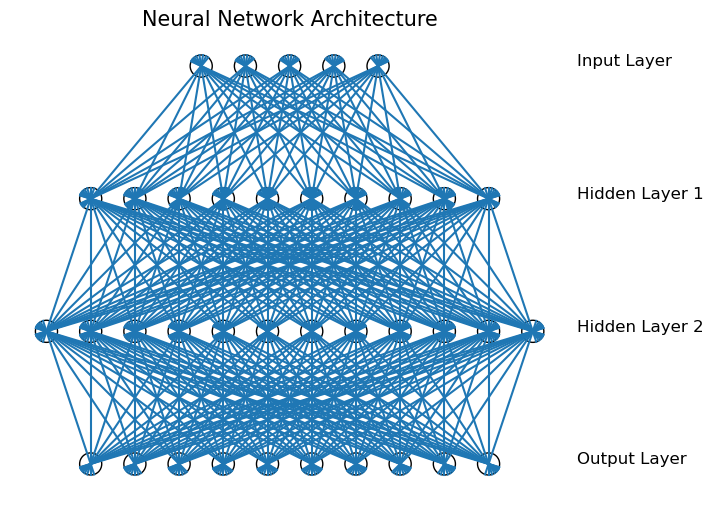

In [ ]:
network = DrawNN([5, 10, 12, 10])
network.draw()


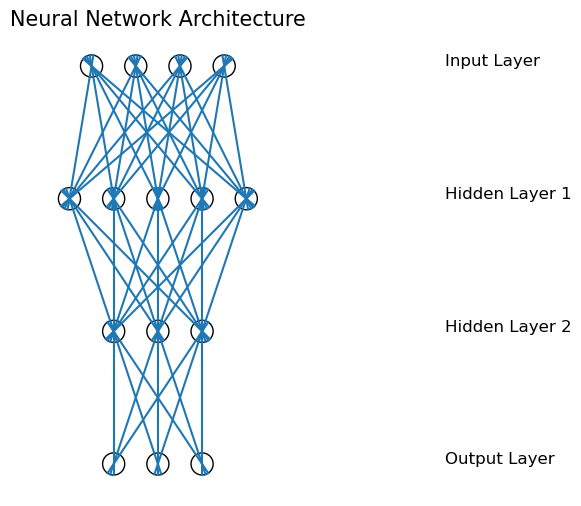

In [ ]:
network = NeuralNetwork(12)  # widest layer size ,just drawing reference (layout only)
network.add_layer(4)
network.add_layer(5)
network.add_layer(3)
network.add_layer(3)

network.draw()